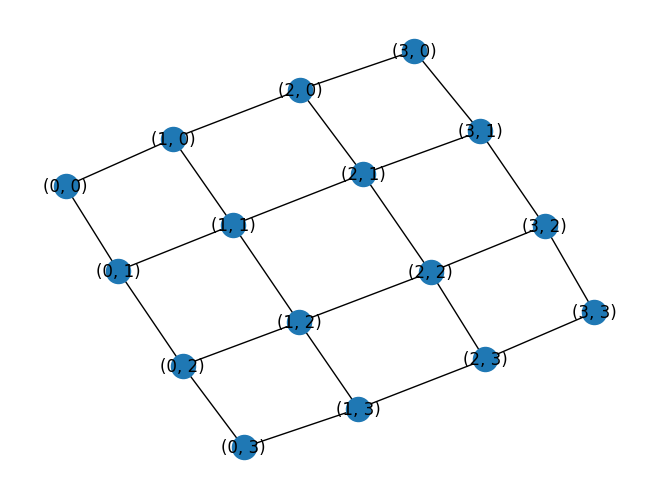

In [112]:
import random
import statistics as stats
import networkx as nx
import matplotlib.pyplot as plt

# graph topology options: k5, cycle, grid
TOPOLOGY = "grid"
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# build different graphs based on input topology
def build_graph(topology: str) -> nx.Graph:
    if topology == "k5":
        return nx.complete_graph(5)
    if topology == "cycle":
        return nx.cycle_graph(12)
    if topology == "grid":
        return nx.grid_2d_graph(4, 4)  # 4x4 grid

g = build_graph(TOPOLOGY)
nx.draw(g, with_labels=True)
plt.show()



In [113]:
# input number of colours for the topology
num_colours = 5 if TOPOLOGY == "k5" else 2

palette = ["red", "blue", "green", "orange", "yellow"]

''' 
simple conflict counting function
reads node colours and returns count of edges with same colour at eaxh end
'''
def count_conflicts(graph, colouring):
    conflicts = 0
    for u, v in graph.edges():
        if colouring[u] == colouring[v]:
            conflicts += 1
    return conflicts

'''
record of conficting nodes
store node pairs that are coflicting in the 'conflicting' set
'''
def conflicting_nodes(graph, colouring):
    conflicting = set()
    for u, v in graph.edges():
        if colouring[u] == colouring[v]:
            conflicting.add(u)
            conflicting.add(v)
    return conflicting

In [114]:
# minimum conflict search experiment

max_steps = 200
num_runs = 20

def run_experiment(graph):

    # randomly colour graph using num_colours
    colouring = {node: random.randint(0, num_colours - 1) for node in graph.nodes()}

    # record number of conflicts through iterations
    conflicts_over_time = [count_conflicts(graph, colouring)]

    # loop for conflict minimising
    for _ in range(max_steps):

        current_conflicts = conflicts_over_time[-1]

        # break when solution is found
        if current_conflicts == 0:
            break

        # pick a conflicting node at randon
        bad_nodes = list(conflicting_nodes(graph, colouring))
        node = random.choice(bad_nodes)

        # store current colour and conflicts to compare with new colour choice 
        current_colour = colouring[node]
        best_colour = current_colour
        best_conflicts = current_conflicts

        # cycle through colours to find one that minimises conflicts
        for c in range(num_colours):

            colouring[node] = c

            # count conflicts for new colour
            new_conflicts = count_conflicts(graph, colouring)

            # update best colour and conflict count based on colours performance
            if new_conflicts < best_conflicts:
                best_conflicts = new_conflicts
                best_colour = c
        
        # record conflict count for best colour and update colouring
        colouring[node] = best_colour
        conflicts_over_time.append(count_conflicts(graph, colouring))

    return colouring, conflicts_over_time

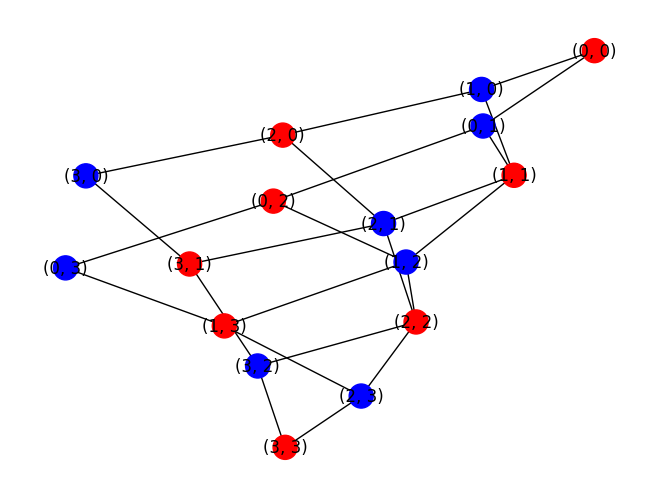

Final conflicts: 0


In [115]:
# run experiment a number of times and store results
all_conflicts = []
end_conflicts = []
steps_to_solution = []
solutions = []

for _ in range(num_runs):
    colouring, conflicts_over_time = run_experiment(g)
    all_conflicts.append(conflicts_over_time)
    end_conflicts.append(conflicts_over_time[-1])
    steps_to_solution.append(len(conflicts_over_time) - 1)
    solutions.append(colouring)

successes = sum(1 for c in end_conflicts if c == 0)

# find index of solution with no conflicts
index = 0
for i, conflicts in enumerate(end_conflicts):
    if conflicts == 0:
        index = i
        break

# store solution
sample_colouring = solutions[index]

# use spring layour for plotting
node_pos = nx.spring_layout(g, seed=RANDOM_SEED)

# convert colour indices to colour from palette for plotting
node_colours_plot = [
    palette[sample_colouring[n]]         
    for n in g.nodes()
]
# plot graph 
nx.draw(g, pos=node_pos, with_labels=True, node_color=node_colours_plot)
plt.show()
print("Final conflicts:", end_conflicts[index])

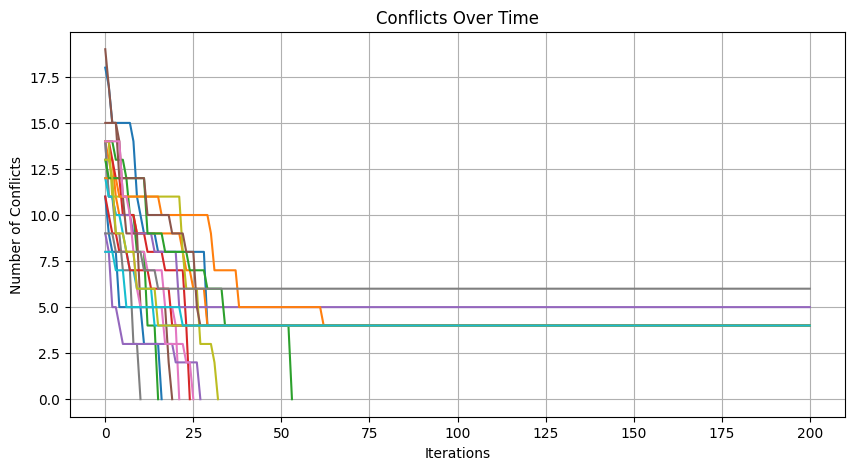

In [127]:
# plot conflict over time for runs
plt.figure(figsize=(10, 5))
for conflicts in all_conflicts:
    plt.plot(conflicts)

plt.title("Conflicts Over Time")
plt.xlabel("Iterations")
plt.ylabel("Number of Conflicts")
plt.grid(True)
plt.show()